In [16]:
# Explainability & Bias Analysis
## Meta Hateful Meme Detection

In [ ]:
from huggingface_hub import login

login("hf_********************************")  # TOKEN MASKED FOR SECURITY

In [18]:
import json, re
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPModel, CLIPProcessor
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.calibration import calibration_curve

In [19]:
from pathlib import Path

DATA_DIR = Path("/kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection")

# handle possible inner 'data/' folder
if (DATA_DIR / "data").exists():
    DATA_DIR = DATA_DIR / "data"

DEV_PATH = DATA_DIR / "dev.jsonl"
IMG_DIR = DATA_DIR / "img"

def resolve_image_path(image_ref):
    """
    Resolve rows that store either:
    - '08291.png'
    - 'img/08291.png'
    - '/kaggle/input/.../img/08291.png'
    """
    p = Path(str(image_ref))

    candidates = []
    if p.is_absolute():
        candidates.append(p)

    # direct join
    candidates.append(IMG_DIR / p)

    # if reference already includes img/
    if len(p.parts) >= 2 and p.parts[0] in {"img", "images"}:
        candidates.append(DATA_DIR / p)
        candidates.append(DATA_DIR / Path(*p.parts[1:]))

    # fallback: search by filename inside IMG_DIR
    candidates.extend(sorted(IMG_DIR.rglob(p.name)))

    seen = set()
    for c in candidates:
        c = Path(c)
        if str(c) in seen:
            continue
        seen.add(str(c))
        if c.exists():
            return c

    raise FileNotFoundError(f"Could not resolve image path for: {image_ref}")

print("Using:", DATA_DIR)
print("DEV exists:", DEV_PATH.exists())
print("IMG exists:", IMG_DIR.exists())


Using: /kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection/data
DEV exists: True
IMG exists: True


In [20]:
def load_jsonl(path):
    with open(path) as f:
        return pd.DataFrame([json.loads(x) for x in f])

def clean_text(x):
    return re.sub(r"\s+", " ", str(x)).strip()

df = load_jsonl(DEV_PATH)
df["clean_text"] = df["text"].apply(clean_text)

print("Samples:", len(df))

Samples: 500


In [21]:
def load_clip():
    try:
        model = CLIPModel.from_pretrained(
            "/kaggle/working/hf_clip_cache/clip-vit-base-patch32",
            local_files_only=True
        )
        processor = CLIPProcessor.from_pretrained(
            "/kaggle/working/hf_clip_cache/clip-vit-base-patch32",
            local_files_only=True
        )
        print("Loaded from cache")
    except:
        print("Downloading from HF...")
        model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
        processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    return model, processor

clip_model, processor = load_clip()

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [22]:
class Model(nn.Module):
    def __init__(self, clip):
        super().__init__()
        self.clip = clip
        for p in self.clip.parameters():
            p.requires_grad = False

        # CLIP base embedding size is 512 for ViT-B/32
        self.fc = nn.Sequential(
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Linear(256, 2)
        )

    def forward(self, pv, ids, mask):
        # Use the raw CLIP submodules and explicitly extract tensors.
        # This avoids returning BaseModelOutputWithPooling objects on some versions.
        vision_out = self.clip.vision_model(pixel_values=pv, return_dict=True)
        text_out = self.clip.text_model(
            input_ids=ids,
            attention_mask=mask,
            return_dict=True
        )

        img_emb = vision_out.pooler_output
        txt_emb = text_out.pooler_output

        if img_emb is None:
            img_emb = vision_out.last_hidden_state[:, 0, :]
        if txt_emb is None:
            txt_emb = text_out.last_hidden_state[:, 0, :]

        img_emb = self.clip.visual_projection(img_emb)
        txt_emb = self.clip.text_projection(txt_emb)

        img_emb = F.normalize(img_emb, dim=-1)
        txt_emb = F.normalize(txt_emb, dim=-1)

        return self.fc(torch.cat([img_emb, txt_emb], dim=-1))

model = Model(clip_model)

In [23]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

ckpt_path = Path("/kaggle/input/notebooks/muddybuddy/09-auroc-optimization/cross_attention_phase2_best.pt")
if not ckpt_path.exists():
    raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")

ckpt = torch.load(ckpt_path, map_location="cpu")
model.load_state_dict(ckpt, strict=False)

model = model.to(DEVICE)
model.eval()

print("Model ready")


Model ready


In [24]:
class MemeDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        try:
            img_path = resolve_image_path(row["img"])
            img = Image.open(img_path).convert("RGB")
        except Exception:
            img = Image.new("RGB", (224, 224))

        enc = processor(
            text=[row["clean_text"]],
            images=img,
            return_tensors="pt",
            padding="max_length",
            truncation=True
        )

        return {
            "pv": enc["pixel_values"].squeeze(),
            "ids": enc["input_ids"].squeeze(),
            "mask": enc["attention_mask"].squeeze(),
            "label": row["label"]
        }


In [25]:
class GradCAM:
    def __init__(self, model):
        self.model = model

    def generate(self, pv, ids, mask):
        pv.requires_grad_()

        out = self.model(pv, ids, mask)
        score = out[:,1].sum()

        self.model.zero_grad()
        score.backward()

        grad = pv.grad.abs().mean(dim=1)[0].cpu().numpy()
        grad = (grad - grad.min())/(grad.max() - grad.min() + 1e-8)

        return grad

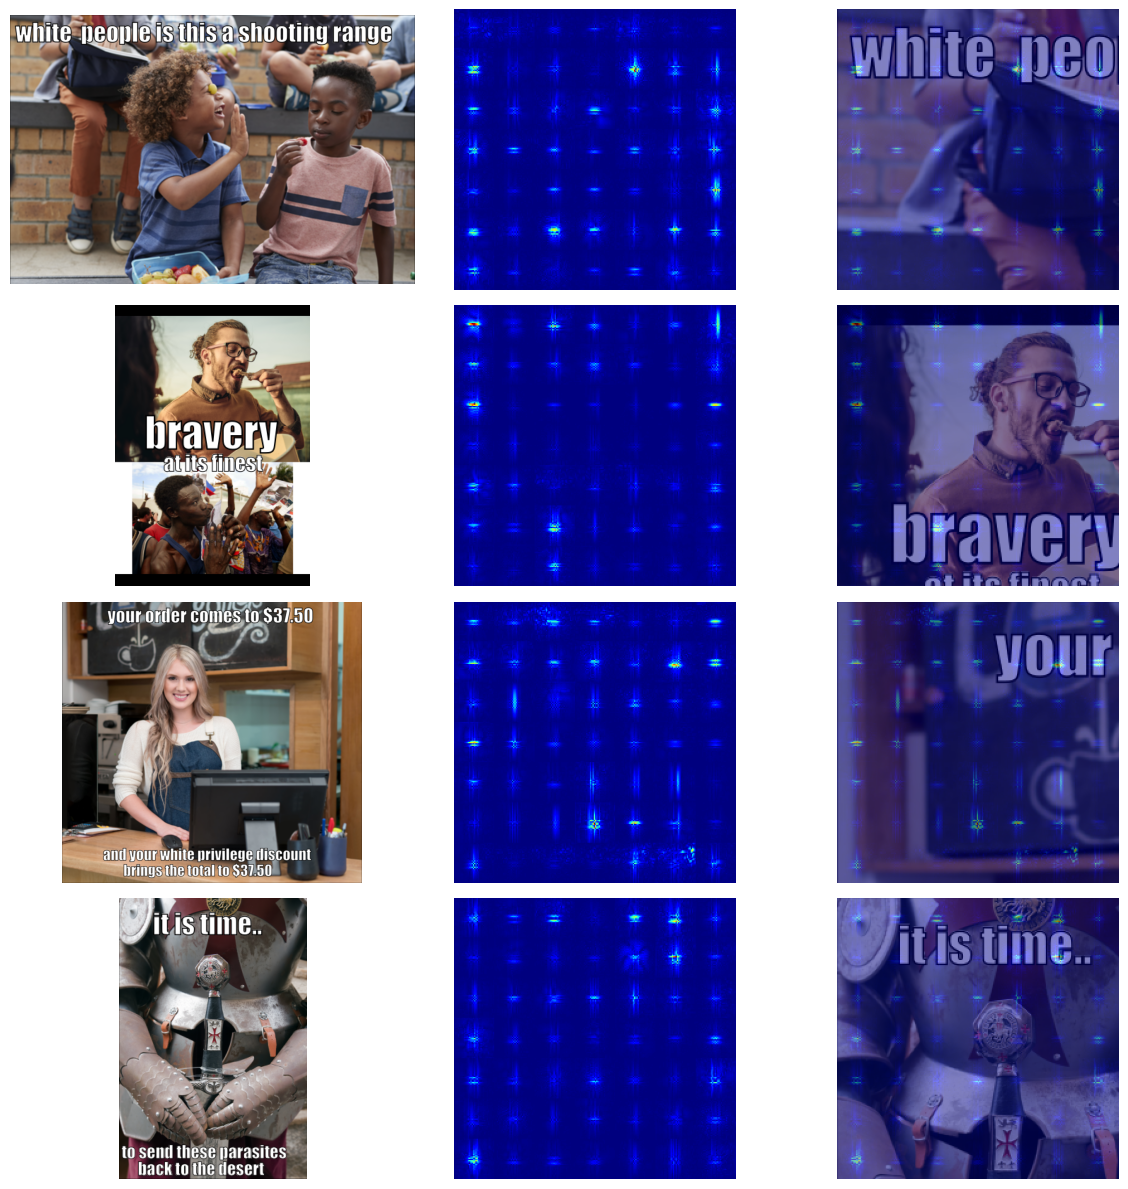

In [26]:
cam = GradCAM(model)

samples = df[df.label == 1].head(4)

fig, ax = plt.subplots(4, 3, figsize=(12, 12))

for i, (_, row) in enumerate(samples.iterrows()):
    try:
        img = Image.open(resolve_image_path(row["img"])).convert("RGB")
    except Exception:
        img = Image.new("RGB", (224, 224))

    enc = processor(text=[row["clean_text"]], images=img, return_tensors="pt")
    pv = enc["pixel_values"].to(DEVICE)
    ids = enc["input_ids"].to(DEVICE)
    mask = enc["attention_mask"].to(DEVICE)

    try:
        heat = cam.generate(pv, ids, mask)
    except Exception as e:
        print(f"GradCAM failed for sample {i}: {e}")
        heat = np.zeros((224, 224), dtype=np.float32)

    ax[i, 0].imshow(img)
    ax[i, 1].imshow(heat, cmap="jet")
    ax[i, 2].imshow(img)
    ax[i, 2].imshow(heat, alpha=0.5, cmap="jet")

    for j in range(3):
        ax[i, j].axis("off")

plt.tight_layout()
plt.show()


In [27]:
loader = DataLoader(MemeDataset(df), batch_size=32)

probs, preds = [], []

with torch.no_grad():
    for b in loader:
        pv = b["pv"].to(DEVICE)
        ids = b["ids"].to(DEVICE)
        mask = b["mask"].to(DEVICE)

        out = model(pv,ids,mask)
        p = torch.softmax(out,1)[:,1]

        probs.extend(p.cpu().numpy())
        preds.extend(out.argmax(1).cpu().numpy())

In [28]:
df["pred"] = preds
df["prob"] = probs

DEM = {
    "race": r"\b(?:black|white|asian|arab)\b",
    "gender": r"\b(?:man|woman)\b",
}

rows=[]

for k,pat in DEM.items():
    sub = df[df.clean_text.str.contains(pat,regex=True,case=False,na=False)]
    if len(sub)<5: continue

    rows.append({
        "group":k,
        "acc":accuracy_score(sub.label,sub.pred),
        "f1":f1_score(sub.label,sub.pred),
        "auroc":roc_auc_score(sub.label,sub.prob)
    })

pd.DataFrame(rows)

,group,acc,f1,auroc
0,race,0.680000,0.809524,0.485294
1,gender,0.333333,0.500000,0.333333


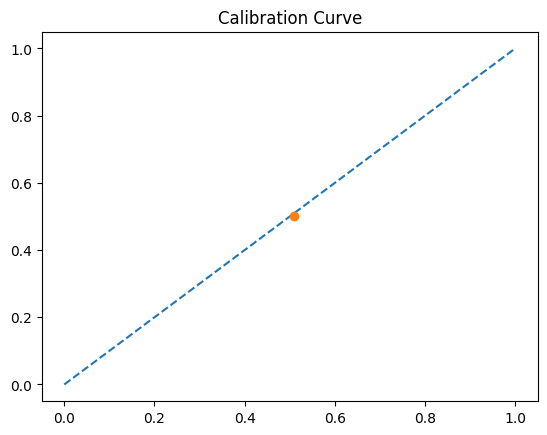

In [29]:
frac, mean = calibration_curve(df.label, df.prob, n_bins=10)

plt.plot([0,1],[0,1],'--')
plt.plot(mean, frac, marker='o')
plt.title("Calibration Curve")
plt.show()